# Project: Genesis — Generative Adversarial Networks (GANs)

## The Concept: Artificial Imagination

We are crossing a fundamental frontier in Artificial Intelligence. Until now, most AI systems have been **Discriminative**: they take data (an image, a price history) and output a label (Cat/Dog, Buy/Sell). They analyze what already exists.

Today, we build a **Generative** system. We are not teaching a machine to analyze; we are teaching it to **create**.

**The Objective:**
To train a **Deep Convolutional GAN (DCGAN)** that generates MNIST-like handwritten digits from random noise. The samples below provide a qualitative check; no statistical test of indistinguishability is performed.

---

## The Architecture: The Adversarial Game

The original GAN objective is a minimax game between two networks. This implementation uses the common non-saturating generator loss described below.

1.  **The Generator ($G$): The Forger.**
    * **Input:** A vector of random noise (Latent Space $z$).
    * **Goal:** To transform that noise into an image $G(z)$ that looks real enough to fool the Discriminator.
    * *It never sees the real data. It learns solely from the feedback of the Discriminator.*

2.  **The Discriminator ($D$): The Detective.**
    * **Input:** An image (either real from the dataset or fake from the Generator).
    * **Goal:** To correctly classify the image as "Real" (1) or "Fake" (0).

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)} [\log D(x)] + \mathbb{E}_{z \sim p_{z}(z)} [\log(1 - D(G(z)))]$$

---

## The Dataset: MNIST

We will use the **MNIST** dataset, the "Hello World" of Computer Vision.
* **Content:** 60,000 images of handwritten digits (0-9).
* **Format:** Grayscale, 28x28 pixels.
* **Why MNIST?** Its small size allows us to train a sophisticated Generative Model on a standard CPU without needing a supercomputer, making the "magic" accessible and reproducible.

---

## The Challenge: Nash Equilibrium

Training a GAN is notoriously difficult. Unlike standard networks that minimize a loss function (finding the bottom of a valley), a GAN seeks a **Nash Equilibrium** (a saddle point where neither player can improve their strategy).

Discriminator saturation can weaken gradients, and the generator can collapse to a small set of outputs. Neither equilibrium nor the absence of mode collapse follows from loss curves alone.

## 1. Environment Setup & Hyperparameters

We begin by importing the necessary frameworks. We rely heavily on **`torchvision`**, which provides direct access to the MNIST dataset and image transformation utilities.

**Key Configuration:**
* **Device:** This run explicitly uses the CPU. While GANs are computationally expensive, the small size of MNIST (28x28) makes it feasible to run on a standard CPU for learning purposes.
* **The Latent Vector ($z$):** We define `NOISE_DIM = 100`. This is the "seed" of imagination. The Generator will take a vector of 100 random numbers and attempt to sculpt an image from it.
* **Reproducibility:** We lock the random seeds to ensure that the "random" noise is consistent across runs, allowing us to scientifically compare results.

In [1]:
# Cell 1: Modified for CPU Speed
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

SEED = 999
random.seed(SEED)
torch.manual_seed(SEED)

IMAGE_SIZE = 32          
BATCH_SIZE = 64        
NOISE_DIM = 100
LR = 0.0002
BETA1 = 0.5
CHANNELS = 1

device = torch.device("cpu") # Forzamos CPU ya que sabemos que estás ahí
print(f"✅ System Configured for Speed (32x32).")

✅ System Configured for Speed (32x32).


## 2. The Data Pipeline: Preparing the Canvas

We now download and process the **MNIST** dataset.

**The Transformation Pipeline:**
Raw images are just grids of numbers [0, 255]. To train a GAN effectively, we must strictly massage this data:
1.  **Resize:** We upscale the native 28x28 images to **32x32**. This powers-of-two size is standard for Convolutional Networks, allowing for clean upsampling/downsampling operations.
2.  **Tensor Conversion:** Convert pixels to PyTorch tensors.
3.  **Normalization:** We scale the pixel values to the range **[-1, 1]**.
    * *Why?* The Generator's final layer uses the `Tanh` activation function, which outputs values in [-1, 1]. Matching the input data range to the output activation range is critical for convergence.

We use a **DataLoader** to feed the data in batches (groups of 64 images), shuffling them every epoch to prevent the Discriminator from memorizing the sequence.

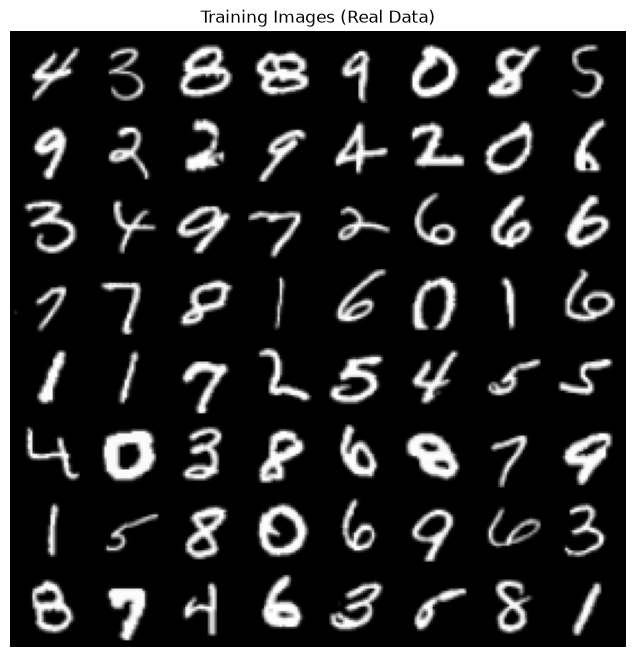

Dataset Loaded.
   Total Images: 60000
   Batch Shape: torch.Size([64, 1, 32, 32]) (Batch, Channels, Height, Width)


In [2]:
# Define the location to save the dataset
dataroot = "./data/mnist"

# Create the dataset with transforms
dataset = dset.MNIST(root=dataroot, download=True, train=True,
                     transform=transforms.Compose([
                         transforms.Resize(IMAGE_SIZE),       # Resize 28 -> 32
                         transforms.ToTensor(),               # Convert to Tensor
                         transforms.Normalize((0.5,), (0.5,)) # Scale to [-1, 1]
                     ]))

# Create the DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE,
                                         shuffle=True, num_workers=2)

# --- VISUALIZATION ---
# Grab a single batch of real images to inspect
real_batch = next(iter(dataloader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images (Real Data)")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

print(f"Dataset Loaded.")
print(f"   Total Images: {len(dataset)}")
print(f"   Batch Shape: {real_batch[0].shape} (Batch, Channels, Height, Width)")

## 3. The Architects: Generator & Discriminator

We now define the neural architectures. We use a convolutional architecture inspired by the **DCGAN paper (Radford et al.)**; this does not guarantee stable training.

### A. The Generator ($G$)
* **Role:** The Artist.
* **Input:** A latent vector $z$ of size 100.
* **Mechanism:** It uses **Transposed Convolutions** (`ConvTranspose2d`) to "upsample" the vector. It starts with a dense block and progressively doubles the spatial size (4x4 $\to$ 8x8 $\to$ 16x16 $\to$ 32x32) while reducing depth.
* **Activation:** `ReLU` for all layers, except the output which uses `Tanh` to force pixel values into $[-1, 1]$.

### B. The Discriminator ($D$)
* **Role:** The Critic.
* **Input:** An image (1x32x32).
* **Mechanism:** It uses standard **Convolutions** (`Conv2d`) with strided steps to downsample the image, extracting features until it outputs a single probability.
* **Activation:** `LeakyReLU` (slope 0.2) to prevent "dying gradients", and `Sigmoid` at the end to output a probability $[0, 1]$.

### C. Weight Initialization
GANs are very sensitive to initial weights. Instead of the default PyTorch initialization, convolution weights use $N(0, 0.02^2)$, BatchNorm scale weights use $N(1, 0.02^2)$, and BatchNorm biases start at zero.

In [3]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z (100)
            # Layer 1: 100 -> 4x4
            nn.ConvTranspose2d(NOISE_DIM, IMAGE_SIZE * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE * 4),
            nn.ReLU(True),
            
            # Layer 2: 4x4 -> 8x8
            nn.ConvTranspose2d(IMAGE_SIZE * 4, IMAGE_SIZE * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE * 2),
            nn.ReLU(True),
            
            # Layer 3: 8x8 -> 16x16
            nn.ConvTranspose2d(IMAGE_SIZE * 2, IMAGE_SIZE, 4, 2, 1, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE),
            nn.ReLU(True),
            
            # Layer 4: 16x16 -> 32x32 (Output)
            nn.ConvTranspose2d(IMAGE_SIZE, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Layer 1: 32x32 -> 16x16
            nn.Conv2d(CHANNELS, IMAGE_SIZE, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 2: 16x16 -> 8x8
            nn.Conv2d(IMAGE_SIZE, IMAGE_SIZE * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 3: 8x8 -> 4x4
            nn.Conv2d(IMAGE_SIZE * 2, IMAGE_SIZE * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 4: 4x4 -> Output (Prob)
            nn.Conv2d(IMAGE_SIZE * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

netG = Generator().to(device)
netG.apply(weights_init)
netD = Discriminator().to(device)
netD.apply(weights_init)

print("Lite Models Built for CPU.")

Lite Models Built for CPU.


## 4. The Training Loop: Adversarial Optimization

This is the engine of the GAN. For each batch of data, we perform two distinct optimization steps:

### Step 1: Train the Discriminator ($D$)
We want to maximize the probability that $D$ correctly classifies real images as "Real" and fake images as "Fake".
* **Pass 1:** Feed real MNIST images. Target Label = 1.
* **Pass 2:** Feed generated images (detached from G). Target Label = 0.
* **Loss:** $-\log D(x) - \log(1 - D(G(z)))$ (minimized)

### Step 2: Train the Generator ($G$)
We want to minimize the probability that $D$ correctly classifies fakes.
* **Pass:** Feed generated images to $D$.
* **Target Label:** **1** (We want to fool $D$ into thinking they are real).
* **Loss:** $-\log D(G(z))$ (the non-saturating loss, minimized)

We track the losses and save a static batch of noise (`fixed_noise`) to visualize the evolution of the *same* "dream" over time.

In [4]:
# 1. Loss Function (Binary Cross Entropy)
criterion = nn.BCELoss()

# 2. Fixed Noise for Visualization
# We generate a constant set of 64 latent vectors.
# We will pass this same noise to the Generator every epoch to see how the images improve.
fixed_noise = torch.randn(64, NOISE_DIM, 1, 1, device=device)

# 3. Optimizers
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

# 4. Training Loop
img_list = []
G_losses = []
D_losses = []
iters = 0
NUM_EPOCHS = 5  # 5 Epochs is enough to see results on MNIST

print(f"Starting Training Loop ({NUM_EPOCHS} Epochs)...")

for epoch in range(NUM_EPOCHS):
    for i, data in enumerate(dataloader, 0):
        
        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ############################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1.0, dtype=torch.float, device=device) # Label 1 = Real
        
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, NOISE_DIM, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(0.0) # Label 0 = Fake
        
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        
        # Add the gradients from the all-real and all-fake batches
        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ############################
        netG.zero_grad()
        label.fill_(1.0)  # fake labels are real for generator cost (The Deception)
        
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print(f"[{epoch}/{NUM_EPOCHS}][{i}/{len(dataloader)}] "
                  f"Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} "
                  f"D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}")

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        
        iters += 1

    # Evaluation samples must not update BatchNorm running statistics.
    was_training = netG.training
    netG.eval()
    with torch.no_grad():
        final_fake_batch = netG(fixed_noise).detach().cpu()
    if was_training:
        netG.train()
    img_list.append(vutils.make_grid(final_fake_batch, padding=2, normalize=True))

print("Training Finished.")

Starting Training Loop (5 Epochs)...


[0/5][0/938] Loss_D: 1.4397 Loss_G: 0.9589 D(x): 0.5856 D(G(z)): 0.5697 / 0.4053


[0/5][50/938] Loss_D: 0.2383 Loss_G: 3.3524 D(x): 0.8699 D(G(z)): 0.0729 / 0.0397


[0/5][100/938] Loss_D: 0.0821 Loss_G: 4.6001 D(x): 0.9493 D(G(z)): 0.0099 / 0.0118


[0/5][150/938] Loss_D: 0.3712 Loss_G: 2.8684 D(x): 0.7797 D(G(z)): 0.0927 / 0.0860


...

[4/5][750/938] Loss_D: 0.3621 Loss_G: 2.2771 D(x): 0.8374 D(G(z)): 0.1472 / 0.1312


[4/5][800/938] Loss_D: 0.2902 Loss_G: 4.2010 D(x): 0.9705 D(G(z)): 0.2036 / 0.0236


[4/5][850/938] Loss_D: 0.2062 Loss_G: 2.2535 D(x): 0.8619 D(G(z)): 0.0284 / 0.1456


[4/5][900/938] Loss_D: 0.2664 Loss_G: 4.9917 D(x): 0.9871 D(G(z)): 0.2072 / 0.0102


Training Finished.


## 5. Results Analysis

The loss curves describe training dynamics, but do not certify convergence, equilibrium, or generalization. We also compare real images and samples from the trained generator. Sample quality and diversity require visual inspection; no held-out generative quality metric is calculated here.


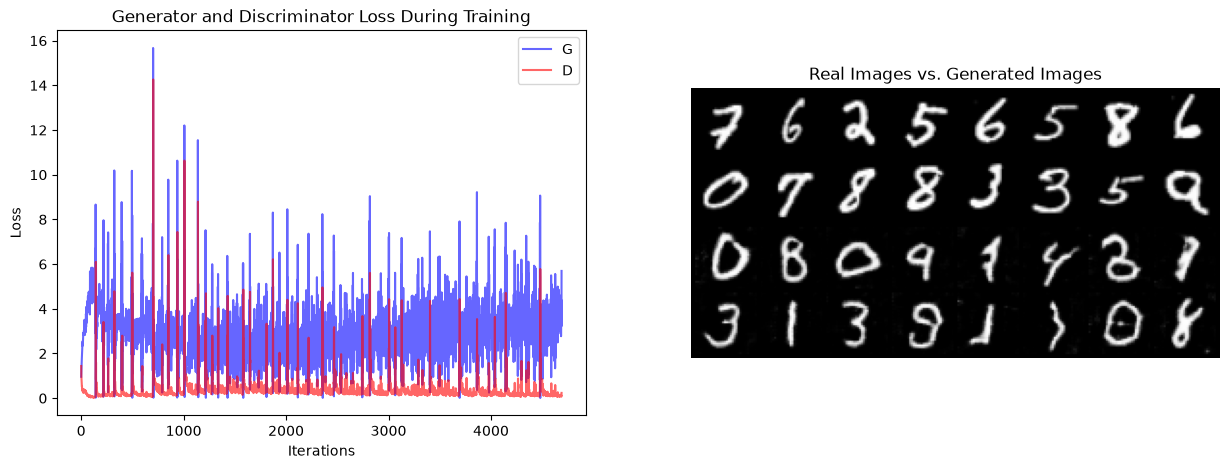

Visual Analysis: Top rows are Real, Bottom rows are Generated.


In [5]:
plt.figure(figsize=(15, 5))

# 1. Plot Losses
plt.subplot(1, 2, 1)
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G", color="blue", alpha=0.6)
plt.plot(D_losses, label="D", color="red", alpha=0.6)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()

# 2. Side-by-Side Comparison
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Real Images vs. Generated Images")

# Fetch Real Batch
real_batch = next(iter(dataloader))

# Plot Real (Top) vs Fake (Bottom) - slightly complex plotting to make it look nice
# We take 16 images from each
real_grid = vutils.make_grid(real_batch[0].to(device)[:16], padding=2, normalize=True).cpu()
fake_grid = vutils.make_grid(final_fake_batch[:16], padding=2, normalize=True).cpu()

# Concatenate them vertically
combined_grid = torch.cat((real_grid, fake_grid), 1) 

plt.imshow(np.transpose(combined_grid, (1, 2, 0)))
plt.show()

print("Visual Analysis: Top rows are Real, Bottom rows are Generated.")

## 6. Training Timelapse

The animation follows the same fixed noise vectors throughout training. Changes show how these particular generated images evolve; they do not measure coverage of all ten digit classes.


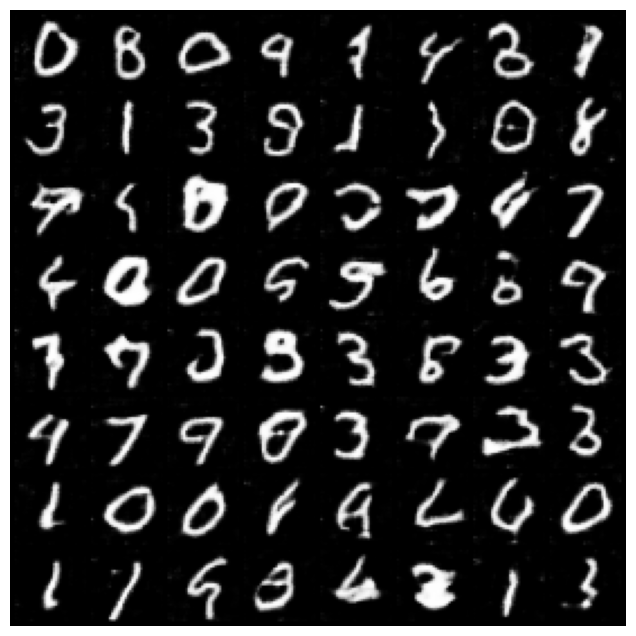

In [6]:
fig = plt.figure(figsize=(8, 8))
plt.axis("off")

ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=500, repeat_delay=1000, blit=True)

# Display the animation in the notebook
HTML(ani.to_jshtml())

## 7. Latent Space Interpolation

We interpolate between two random latent vectors in 12 steps and display the corresponding images in evaluation mode. Smooth changes are expected from a continuous network, and do not establish that it avoided memorization or learned every handwriting mode.


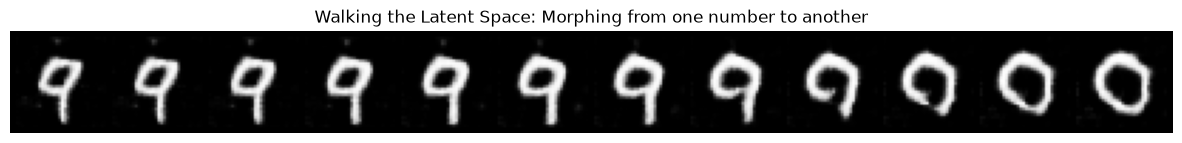

Look at the transition. Can you see the digit mutating?


In [7]:
# 1. Generate two random points in the latent space
z_start = torch.randn(1, NOISE_DIM, 1, 1, device=device) # Point A
z_end   = torch.randn(1, NOISE_DIM, 1, 1, device=device) # Point B

# 2. Create interpolation steps (Walking from A to B)
steps = 12
interpolation = []

for alpha in np.linspace(0, 1, steps):
    # Linear Interpolation: z = (1-alpha)*A + alpha*B
    z_step = (1 - alpha) * z_start + alpha * z_end
    interpolation.append(z_step)

# Stack them into a single batch
interp_batch = torch.cat(interpolation, 0)

# 3. Generate images without updating BatchNorm statistics.
netG.eval()
with torch.no_grad():
    fake_interp = netG(interp_batch).detach().cpu()

# 4. Visualize the Morphing
plt.figure(figsize=(15, 4))
plt.axis("off")
plt.title("Walking the Latent Space: Morphing from one number to another")
plt.imshow(np.transpose(vutils.make_grid(fake_interp, padding=2, normalize=True, nrow=steps), (1, 2, 0)))
plt.show()

print("Look at the transition. Can you see the digit mutating?")

## 8. Conclusion

This notebook trains a DCGAN on MNIST for five epochs and provides samples, loss curves, a timelapse, and latent interpolation. These are qualitative diagnostics. Establishing generalization and diversity would require held-out metrics and explicit checks for memorization and mode collapse. The trained networks remain in memory; this notebook does not export a model checkpoint.
